#**C-C chemokine receptor type 5_Rene Mih_2026_UB-CeDD**


# **Part 1: Data Collection & Curation**

**First we need to connect Google Colab with our Google Drive, so that we can have access to our Google drive within Colab.**

This allows us to:
* Save datasets
* Reload data across sessions
* Organize project files

In [1]:
from google.colab import drive
drive.mount('/content/gdrive/', force_remount=True)

Mounted at /content/gdrive/


**Now create "data" folder in our "Colab Notebooks" folder on Google Drive.**

In [2]:
! mkdir "/content/gdrive/My Drive/Colab Notebooks/data"

mkdir: cannot create directory ‘/content/gdrive/My Drive/Colab Notebooks/data’: File exists


## Install and Import Required Libraries
We install the ChEMBL web service package so that we can retrieve bioactivity data

In [3]:
!pip install chembl_webresource_client

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.9 MB/s eta 0:00:00


# Step 1: Search for Traget Protein

## **Target Identification (HIV)**
Search ChEMBL for the HIV target and select the most relevant entry.

# Import Libraries
* pandas for data handling
* new_client from chembl for accessing the database

In [4]:
import pandas as pd
from chembl_webresource_client.new_client import new_client

## **Target Identification (CHEMBL274)**
Search ChEMBL for the C-C chemokine receptor type 5 target (CHEMBL274) and select the most relevant entry.

In [5]:
target = new_client.target
target_query = target.search("CHEMBL274")
targets = pd.DataFrame.from_dict(target_query)
targets.head()

,cross_references,organism,pref_name,score,species_group_flag,target_chembl_id,target_components,target_type,tax_id
0,[],Homo sapiens,C-C chemokine receptor type 5,16.0,False,CHEMBL274,"[{'accession': 'P51681', 'component_descriptio...",SINGLE PROTEIN,9606
1,[],Homo sapiens,CCR5/mu opioid receptor complex,11.0,False,CHEMBL3301384,"[{'accession': 'P51681', 'component_descriptio...",PROTEIN COMPLEX,9606


**Reterive Bioactivity data for selected target**

**Now retrieve only bioactivity data for target; **HIV(CHEMBL274)** with reported IC 50  values in nM (nanomolar) unit.**

In [6]:
selected_target = targets.target_chembl_id[0]
activity = new_client.activity
results = activity.filter(target_chembl_id=selected_target).filter(standard_type="IC50")

In [7]:
df1 = pd.DataFrame.from_dict(results)
display(df1.head(5))
display(df1.standard_type.unique())

,action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,...,target_organism,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value
0,None,None,75508,[],CHEMBL654653,Binding affinity against C-C chemokine recepto...,B,None,None,BAO_0000190,...,Homo sapiens,C-C chemokine receptor type 5,9606,None,None,IC50,nM,UO_0000065,None,335.0
1,None,None,75509,[],CHEMBL654653,Binding affinity against C-C chemokine recepto...,B,None,None,BAO_0000190,...,Homo sapiens,C-C chemokine receptor type 5,9606,None,None,IC50,nM,UO_0000065,None,28.0
2,None,None,75510,[],CHEMBL654653,Binding affinity against C-C chemokine recepto...,B,None,None,BAO_0000190,...,Homo sapiens,C-C chemokine receptor type 5,9606,None,None,IC50,nM,UO_0000065,None,10.0
3,None,None,76739,[],CHEMBL873385,Binding affinity against human CCR5 receptor s...,B,None,None,BAO_0000190,...,Homo sapiens,C-C chemokine receptor type 5,9606,None,None,IC50,nM,UO_0000065,None,35.0
4,None,None,77749,[],CHEMBL654653,Binding affinity against C-C chemokine recepto...,B,None,None,BAO_0000190,...,Homo sapiens,C-C chemokine receptor type 5,9606,None,None,IC50,nM,UO_0000065,None,15.0


array(['IC50'], dtype=object)

**Finally Save the resulting bioactivity data to a CSV file** **bioactivity_raw_data.csv**.

In [8]:
df1.to_csv('bioactivity_raw_data.csv', index=False)

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Now copy "bioactivity_raw_data.csv" file to Google Drive, in foler "data"**

In [10]:
! cp bioactivity_raw_data.csv "/content/gdrive/My Drive/Colab Notebooks/data"

cp: failed to access '/content/gdrive/My Drive/Colab Notebooks/data': Transport endpoint is not connected


In [11]:
! ls -l "/content/gdrive/My Drive/Colab Notebooks/data"

ls: cannot access '/content/gdrive/My Drive/Colab Notebooks/data': Transport endpoint is not connected


In [12]:
! head bioactivity_raw_data.csv

action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,bao_format,bao_label,canonical_smiles,data_validity_comment,data_validity_description,document_chembl_id,document_journal,document_year,ligand_efficiency,molecule_chembl_id,molecule_pref_name,parent_molecule_chembl_id,pchembl_value,potential_duplicate,qudt_units,record_id,relation,src_id,standard_flag,standard_relation,standard_text_value,standard_type,standard_units,standard_upper_value,standard_value,target_chembl_id,target_organism,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value
,,75508,[],CHEMBL654653,Binding affinity against C-C chemokine receptor type 5 stably expressed in Chinese hamster ovary (CHO) cells using [125I]-MIP-1 alpha as the radioligand,B,,,BAO_0000190,BAO_0000219,cell-based format,C=CCN(C(=O)OCc1ccc([N+](=O)[O-])cc1)C1CCN(CCC(Cn2nnnc2-c2ccccc2)c2ccccc2)CC1,,,CHEMBL11

In [13]:
df1.standard_type.unique()

array(['IC50'], dtype=object)

# **Step 2: Bioactivity Data Retrieval (IC50)**
**Retrieve bioactivity data (IC50) for the selected BRCA1 target.**

**Inspect Missing Values**

In [14]:
df1["standard_type"].isna().sum()

np.int64(0)

**Filter Rows with Valid Bioactivity Values**

In [15]:
df2 = df1[df1["standard_value"].notna()]
df2.head()

,action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,...,target_organism,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value
0,None,None,75508,[],CHEMBL654653,Binding affinity against C-C chemokine recepto...,B,None,None,BAO_0000190,...,Homo sapiens,C-C chemokine receptor type 5,9606,None,None,IC50,nM,UO_0000065,None,335.0
1,None,None,75509,[],CHEMBL654653,Binding affinity against C-C chemokine recepto...,B,None,None,BAO_0000190,...,Homo sapiens,C-C chemokine receptor type 5,9606,None,None,IC50,nM,UO_0000065,None,28.0
2,None,None,75510,[],CHEMBL654653,Binding affinity against C-C chemokine recepto...,B,None,None,BAO_0000190,...,Homo sapiens,C-C chemokine receptor type 5,9606,None,None,IC50,nM,UO_0000065,None,10.0
3,None,None,76739,[],CHEMBL873385,Binding affinity against human CCR5 receptor s...,B,None,None,BAO_0000190,...,Homo sapiens,C-C chemokine receptor type 5,9606,None,None,IC50,nM,UO_0000065,None,35.0
4,None,None,77749,[],CHEMBL654653,Binding affinity against C-C chemokine recepto...,B,None,None,BAO_0000190,...,Homo sapiens,C-C chemokine receptor type 5,9606,None,None,IC50,nM,UO_0000065,None,15.0


**Assign Bioactivity Classes**
Define active, intermediate, and inactive classes based on IC50 values.


In [16]:
bioactivity_class = []
for value in df2.standard_value:
    value = float(value)
    if value >= 10000:
        bioactivity_class.append("inactive")
    elif value <= 1000:
        bioactivity_class.append("active")
    else:
        bioactivity_class.append("intermediate")

**Extract Relevant Columns**

In [17]:
molecule_ids = df2.molecule_chembl_id.tolist()
canonical_smiles = df2.canonical_smiles.tolist()
standard_values = df2.standard_value.tolist()

In [18]:
data = list(zip(
    molecule_ids,
    canonical_smiles,
    standard_values,
        bioactivity_class,
))

**Create Preprocessed bioactivity Dataset**

In [19]:

df3 = pd.DataFrame(
    data,
    columns=[
        "molecule_chembl_id",
        "canonical_smiles",
        "standard_value",
        "bioactivity_class",
    ]
)
df3.head()

,molecule_chembl_id,canonical_smiles,standard_value,bioactivity_class
0,CHEMBL105460,C=CCN(C(=O)OCc1ccc([N+](=O)[O-])cc1)C1CCN(CCC(...,335.0,active
1,CHEMBL105606,C=CCN(C(=O)OCc1ccc([N+](=O)[O-])cc1)C1CCN(CCC(...,28.0,active
2,CHEMBL105570,C=CCN(C(=O)OCc1ccc([N+](=O)[O-])cc1)C1CCN(CCC(...,10.0,active
3,CHEMBL83338,CN(C[C@@H](CCN1CCC2(CC1)C[S+]([O-])c1ccccc12)c...,35.0,active
4,CHEMBL325357,C=CCN(C(=O)OCc1ccc([N+](=O)[O-])cc1)C1CCN(CCC(...,15.0,active


**Remove Compounds without Valid SMILES**. Drop rows with **NaN**, **empty** or **None** SMILES values.

In [20]:
df3 = df3.dropna(subset=["canonical_smiles"])
df3 = df3[df3["canonical_smiles"].str.lower() != "none"]
df3 = df3[df3["canonical_smiles"].str.strip() != ""]
df3.head()

,molecule_chembl_id,canonical_smiles,standard_value,bioactivity_class
0,CHEMBL105460,C=CCN(C(=O)OCc1ccc([N+](=O)[O-])cc1)C1CCN(CCC(...,335.0,active
1,CHEMBL105606,C=CCN(C(=O)OCc1ccc([N+](=O)[O-])cc1)C1CCN(CCC(...,28.0,active
2,CHEMBL105570,C=CCN(C(=O)OCc1ccc([N+](=O)[O-])cc1)C1CCN(CCC(...,10.0,active
3,CHEMBL83338,CN(C[C@@H](CCN1CCC2(CC1)C[S+]([O-])c1ccccc12)c...,35.0,active
4,CHEMBL325357,C=CCN(C(=O)OCc1ccc([N+](=O)[O-])cc1)C1CCN(CCC(...,15.0,active


**Save Preprocessed Bioactivity Data.** Save the cleaned dataset to CSV and copy to Google Drive.

In [21]:
df3.to_csv("bioactivity_preprocessed_data.csv", index=False)

!cp bioactivity_preprocessed_data.csv "/content/gdrive/My Drive/Colab Notebooks/data"
!ls "/content/gdrive/My Drive/Colab Notebooks/data"

cp: failed to access '/content/gdrive/My Drive/Colab Notebooks/data': Transport endpoint is not connected
ls: cannot access '/content/gdrive/My Drive/Colab Notebooks/data': Transport endpoint is not connected


# **Part 2: Exploratory Data Analysis**

## **Import Libraries**

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='ticks')

## **Import Bioactivity Dataset**

In [ ]:
from google.colab import files
uploaded = files.upload()

In [23]:
df4 = pd.read_csv("bioactivity_preprocessed_data.csv")
df4.head(10)

,molecule_chembl_id,canonical_smiles,standard_value,bioactivity_class
0,CHEMBL105460,C=CCN(C(=O)OCc1ccc([N+](=O)[O-])cc1)C1CCN(CCC(...,335.0,active
1,CHEMBL105606,C=CCN(C(=O)OCc1ccc([N+](=O)[O-])cc1)C1CCN(CCC(...,28.0,active
2,CHEMBL105570,C=CCN(C(=O)OCc1ccc([N+](=O)[O-])cc1)C1CCN(CCC(...,10.0,active
3,CHEMBL83338,CN(C[C@@H](CCN1CCC2(CC1)C[S+]([O-])c1ccccc12)c...,35.0,active
4,CHEMBL325357,C=CCN(C(=O)OCc1ccc([N+](=O)[O-])cc1)C1CCN(CCC(...,15.0,active
5,CHEMBL105572,C=CCN(C(=O)OCc1ccc([N+](=O)[O-])cc1)C1CCN(CCC(...,16.0,active
6,CHEMBL107750,C=CCN(C(=O)OCc1ccc([N+](=O)[O-])cc1)C1CCN(CCC(...,15.0,active
7,CHEMBL105659,C=CCN(C(=O)OCc1ccccc1)C1CCN(CCC(C)(Cn2cnc3cccc...,112.0,active
8,CHEMBL107380,C=CCN(C(=O)OCc1ccc([N+](=O)[O-])cc1)C1CCN(CCC(...,10.0,active
9,CHEMBL104793,C=CCN(C(=O)OCc1ccccc1)C1CCN(CCC(CN2C(=O)N[C@H]...,7.0,active


## **Remove NA Values**

In [24]:
print("Original shape:", df4.shape)

df4 = df4.dropna(subset=[
    "molecule_chembl_id",
    "canonical_smiles",
    "standard_value"
])

# convert IC50 to numeric
df4["standard_value"] = pd.to_numeric(df4["standard_value"], errors="coerce")

df4 = df4.dropna(subset=["standard_value"])

df4 = df4[df4["bioactivity_class"] != 'intermediate']

print("After cleaning:", df4.shape)



Original shape: (3093, 4)
After cleaning: (2819, 4)


In [25]:
df4.head()

,molecule_chembl_id,canonical_smiles,standard_value,bioactivity_class
0,CHEMBL105460,C=CCN(C(=O)OCc1ccc([N+](=O)[O-])cc1)C1CCN(CCC(...,335.0,active
1,CHEMBL105606,C=CCN(C(=O)OCc1ccc([N+](=O)[O-])cc1)C1CCN(CCC(...,28.0,active
2,CHEMBL105570,C=CCN(C(=O)OCc1ccc([N+](=O)[O-])cc1)C1CCN(CCC(...,10.0,active
3,CHEMBL83338,CN(C[C@@H](CCN1CCC2(CC1)C[S+]([O-])c1ccccc12)c...,35.0,active
4,CHEMBL325357,C=CCN(C(=O)OCc1ccc([N+](=O)[O-])cc1)C1CCN(CCC(...,15.0,active


## **Aggregate Duplicates IC50 (median IC50 per canonical smile)**

In [26]:
df_clean = (
    df4
    .groupby("canonical_smiles", as_index=False)
    .agg({
        "molecule_chembl_id": "first",
        "standard_value": "median",
        "bioactivity_class": "first"
    })
)

print("Before aggregation:", df4.shape[0])
print("After aggregation:", df_clean.shape[0])

df_clean.head()


Before aggregation: 2819
After aggregation: 2049


,canonical_smiles,molecule_chembl_id,standard_value,bioactivity_class
0,BrCc1ccc2ccc3ccc(CBr)nc3c2n1,CHEMBL1976682,202263.115,inactive
1,Brc1ccc(COc2ccc(Br)cc2N2CCOCC2)cc1,CHEMBL2281892,1000.000,active
2,Brc1cccc([C@H]2CN(Cc3ccccc3)C[C@@H]2CN2CCC(c3c...,CHEMBL93691,1000.000,active
3,C/C(=N\NC(=N)N)c1cc(Br)ccc1OCc1ccc(C#N)cc1,CHEMBL2281960,92.900,active
4,C/C(=N\NC(=N)N)c1cc(Br)ccc1OCc1ccc(Cl)cc1,CHEMBL241097,199.995,active


In [27]:
df_clean.standard_value.describe()

,standard_value
count,2.049000e+03
mean,1.689737e+04
std,2.036455e+05
min,3.000000e-03
25%,3.010000e+00
50%,2.400000e+01
75%,1.950000e+02
max,5.090000e+06


## **Convert IC50 to pIC50**

Convert IC50 to the negative logarithmic scale which is essentially -log10(IC50). This conversion allows IC50 data to be more uniformly distributed.

In [28]:
df_clean["pIC50"] = -np.log10(df_clean["standard_value"] * 1e-9)

df_clean.head()

,canonical_smiles,molecule_chembl_id,standard_value,bioactivity_class,pIC50
0,BrCc1ccc2ccc3ccc(CBr)nc3c2n1,CHEMBL1976682,202263.115,inactive,3.694083
1,Brc1ccc(COc2ccc(Br)cc2N2CCOCC2)cc1,CHEMBL2281892,1000.000,active,6.000000
2,Brc1cccc([C@H]2CN(Cc3ccccc3)C[C@@H]2CN2CCC(c3c...,CHEMBL93691,1000.000,active,6.000000
3,C/C(=N\NC(=N)N)c1cc(Br)ccc1OCc1ccc(C#N)cc1,CHEMBL2281960,92.900,active,7.031984
4,C/C(=N\NC(=N)N)c1cc(Br)ccc1OCc1ccc(Cl)cc1,CHEMBL241097,199.995,active,6.698981


In [29]:
threshold = 6

df_clean["bioactivity_class"] = np.where(
    df_clean["pIC50"] >= threshold,
    "active",
    "inactive"
)

df_clean.head()


,canonical_smiles,molecule_chembl_id,standard_value,bioactivity_class,pIC50
0,BrCc1ccc2ccc3ccc(CBr)nc3c2n1,CHEMBL1976682,202263.115,inactive,3.694083
1,Brc1ccc(COc2ccc(Br)cc2N2CCOCC2)cc1,CHEMBL2281892,1000.000,active,6.000000
2,Brc1cccc([C@H]2CN(Cc3ccccc3)C[C@@H]2CN2CCC(c3c...,CHEMBL93691,1000.000,active,6.000000
3,C/C(=N\NC(=N)N)c1cc(Br)ccc1OCc1ccc(C#N)cc1,CHEMBL2281960,92.900,active,7.031984
4,C/C(=N\NC(=N)N)c1cc(Br)ccc1OCc1ccc(Cl)cc1,CHEMBL241097,199.995,active,6.698981


## **Check Duplicates**

In [30]:
print("Duplicate SMILES remaining:",
      df_clean["canonical_smiles"].duplicated().sum())


Duplicate SMILES remaining: 0


In [31]:
df_clean.standard_value.describe()

,standard_value
count,2.049000e+03
mean,1.689737e+04
std,2.036455e+05
min,3.000000e-03
25%,3.010000e+00
50%,2.400000e+01
75%,1.950000e+02
max,5.090000e+06


In [32]:
df_clean.pIC50.describe()

,pIC50
count,2049.000000
mean,7.456178
std,1.435921
min,2.293282
25%,6.709965
50%,7.619789
75%,8.521434
max,11.522879


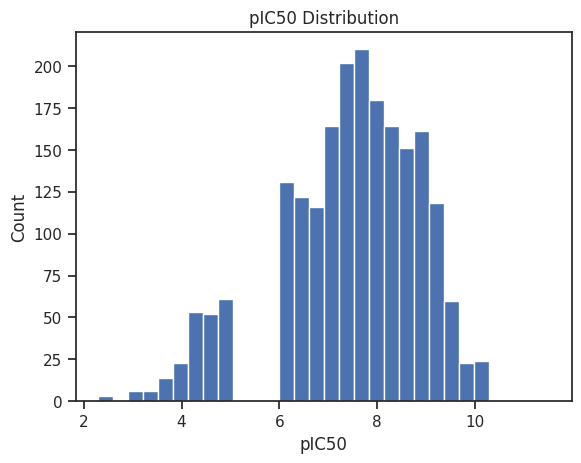

<Figure size 640x480 with 0 Axes>

In [33]:
plt.hist(df_clean["pIC50"], bins=30)
plt.xlabel("pIC50")
plt.ylabel("Count")
plt.title("pIC50 Distribution")
plt.show()
plt.savefig('histogram_pic50.pdf')

# **Lipinski's Descriptor Calculation**

Christopher Lipinski, a scientist at Pfizer, came up with a set of rule-of-thumb for evaluating the druglikeness of compounds. Such druglikeness is based on the Absorption, Distribution, Metabolism and Excretion (ADME) that is also known as the pharmacokinetic profile. Lipinski analyzed all orally active FDA-approved drugs in the formulation of what is to be known as the Rule-of-Five or Lipinski's Rule.

The Lipinski's Rule stated the following:

**Molecular weight < 500 Dalton**  
**Octanol-water partition coefficient (LogP) < 5**  
**Hydrogen bond donors < 5**  
**Hydrogen bond acceptors < 10**

## **Install rdkit**

In [34]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 49.9 MB/s eta 0:00:00


In [35]:
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski
from rdkit.Chem import rdMolDescriptors

In [36]:
df_no_smiles = df_clean.drop(columns='canonical_smiles')

smiles = []

for i in df_clean.canonical_smiles.tolist():
  cpd = str(i).split('.')
  cpd_longest = max(cpd, key=len)
  smiles.append(cpd_longest)

smiles = pd.Series(smiles, name='canonical_smiles')

df_clean_smiles = pd.concat([df_no_smiles, smiles], axis=1)

df_clean_smiles


,molecule_chembl_id,standard_value,bioactivity_class,pIC50,canonical_smiles
0,CHEMBL1976682,202263.115,inactive,3.694083,BrCc1ccc2ccc3ccc(CBr)nc3c2n1
1,CHEMBL2281892,1000.000,active,6.000000,Brc1ccc(COc2ccc(Br)cc2N2CCOCC2)cc1
2,CHEMBL93691,1000.000,active,6.000000,Brc1cccc([C@H]2CN(Cc3ccccc3)C[C@@H]2CN2CCC(c3c...
3,CHEMBL2281960,92.900,active,7.031984,C/C(=N\NC(=N)N)c1cc(Br)ccc1OCc1ccc(C#N)cc1
4,CHEMBL241097,199.995,active,6.698981,C/C(=N\NC(=N)N)c1cc(Br)ccc1OCc1ccc(Cl)cc1
...,...,...,...,...,...
2044,CHEMBL330065,220.000,active,6.657577,c1ccc(CN2C[C@H](CN3CCC(c4ccccc4)CC3)[C@@H](c3c...
2045,CHEMBL90015,255.000,active,6.593460,c1ccc(CN2C[C@H](CN3CCC(c4ccccc4)CC3)[C@@H](c3c...
2046,CHEMBL1093137,10000.000,inactive,5.000000,c1ccc(CNCc2ccc(CN(Cc3nc4ccccc4[nH]3)[C@H]3CCCc...
2047,CHEMBL3608763,36000.000,inactive,4.443697,c1ccc(Cc2cn[nH]c2C2CCN(Cc3ccncc3)CC2)cc1


## **Calculate descriptors**

In [37]:
def lipinski(smiles, verbose=False):

    moldata= []
    for elem in smiles:
        mol=Chem.MolFromSmiles(elem)
        moldata.append(mol)

    baseData= np.arange(1,1)
    i=0
    for mol in moldata:

        desc_MolWt = Descriptors.MolWt(mol)
        desc_MolLogP = Descriptors.MolLogP(mol)
        desc_NumHDonors = Lipinski.NumHDonors(mol)
        desc_NumHAcceptors = Lipinski.NumHAcceptors(mol)

        row = np.array([desc_MolWt,
                        desc_MolLogP,
                        desc_NumHDonors,
                        desc_NumHAcceptors])

        if(i==0):
            baseData=row
        else:
            baseData=np.vstack([baseData, row])
        i=i+1

    columnNames=["MW","LogP","NumHDonors","NumHAcceptors"]
    descriptors = pd.DataFrame(data=baseData,columns=columnNames)

    return descriptors



In [38]:
df_lipinski = lipinski(df_clean_smiles.canonical_smiles)
df_lipinski.head()

,MW,LogP,NumHDonors,NumHAcceptors
0,366.056,4.57280,0.0,2.0
1,427.136,4.62720,0.0,3.0
2,489.501,6.54430,0.0,2.0
3,386.253,3.10685,3.0,4.0
4,395.688,3.88857,3.0,3.0


In [39]:
df_lipinski.shape

(2049, 4)

Combine Both datasets

In [40]:
df_clean_smiles.head()

,molecule_chembl_id,standard_value,bioactivity_class,pIC50,canonical_smiles
0,CHEMBL1976682,202263.115,inactive,3.694083,BrCc1ccc2ccc3ccc(CBr)nc3c2n1
1,CHEMBL2281892,1000.000,active,6.000000,Brc1ccc(COc2ccc(Br)cc2N2CCOCC2)cc1
2,CHEMBL93691,1000.000,active,6.000000,Brc1cccc([C@H]2CN(Cc3ccccc3)C[C@@H]2CN2CCC(c3c...
3,CHEMBL2281960,92.900,active,7.031984,C/C(=N\NC(=N)N)c1cc(Br)ccc1OCc1ccc(C#N)cc1
4,CHEMBL241097,199.995,active,6.698981,C/C(=N\NC(=N)N)c1cc(Br)ccc1OCc1ccc(Cl)cc1


In [41]:
df_lipinski.head()

,MW,LogP,NumHDonors,NumHAcceptors
0,366.056,4.57280,0.0,2.0
1,427.136,4.62720,0.0,3.0
2,489.501,6.54430,0.0,2.0
3,386.253,3.10685,3.0,4.0
4,395.688,3.88857,3.0,3.0


In [42]:
df_combined = pd.concat([df_clean_smiles, df_lipinski], axis=1)
df_combined.head()

,molecule_chembl_id,standard_value,bioactivity_class,pIC50,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors
0,CHEMBL1976682,202263.115,inactive,3.694083,BrCc1ccc2ccc3ccc(CBr)nc3c2n1,366.056,4.57280,0.0,2.0
1,CHEMBL2281892,1000.000,active,6.000000,Brc1ccc(COc2ccc(Br)cc2N2CCOCC2)cc1,427.136,4.62720,0.0,3.0
2,CHEMBL93691,1000.000,active,6.000000,Brc1cccc([C@H]2CN(Cc3ccccc3)C[C@@H]2CN2CCC(c3c...,489.501,6.54430,0.0,2.0
3,CHEMBL2281960,92.900,active,7.031984,C/C(=N\NC(=N)N)c1cc(Br)ccc1OCc1ccc(C#N)cc1,386.253,3.10685,3.0,4.0
4,CHEMBL241097,199.995,active,6.698981,C/C(=N\NC(=N)N)c1cc(Br)ccc1OCc1ccc(Cl)cc1,395.688,3.88857,3.0,3.0


In [43]:
df_combined = df_combined.drop(columns="standard_value")
df_combined.head()

,molecule_chembl_id,bioactivity_class,pIC50,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors
0,CHEMBL1976682,inactive,3.694083,BrCc1ccc2ccc3ccc(CBr)nc3c2n1,366.056,4.57280,0.0,2.0
1,CHEMBL2281892,active,6.000000,Brc1ccc(COc2ccc(Br)cc2N2CCOCC2)cc1,427.136,4.62720,0.0,3.0
2,CHEMBL93691,active,6.000000,Brc1cccc([C@H]2CN(Cc3ccccc3)C[C@@H]2CN2CCC(c3c...,489.501,6.54430,0.0,2.0
3,CHEMBL2281960,active,7.031984,C/C(=N\NC(=N)N)c1cc(Br)ccc1OCc1ccc(C#N)cc1,386.253,3.10685,3.0,4.0
4,CHEMBL241097,active,6.698981,C/C(=N\NC(=N)N)c1cc(Br)ccc1OCc1ccc(Cl)cc1,395.688,3.88857,3.0,3.0


In [44]:
# Save CSV
df_combined.to_csv("df_lipinski.csv", index=False)

## **Exploratory Data Analysis or Chemical Space Analysis For Lipinski Descriptors**

## **Barplot of the bioactivity classes**

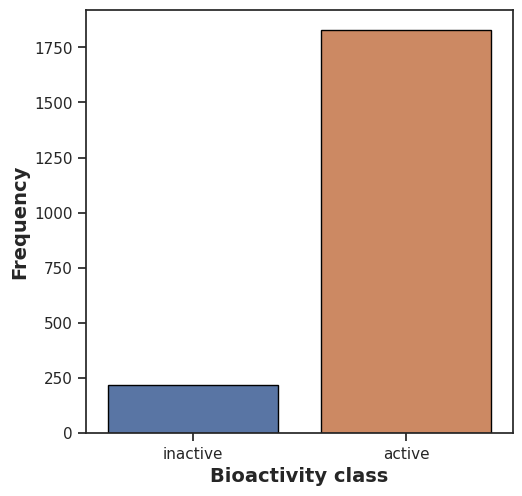

In [45]:
plt.figure(figsize=(5.5, 5.5))

sns.countplot(x="bioactivity_class", data= df_combined, hue="bioactivity_class", edgecolor='black')

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')

plt.savefig('barplot_bioactivity_class.pdf')

## **Boxplot of the bioactivity classes for PIC50**

Text(0, 0.5, 'pIC50 value')

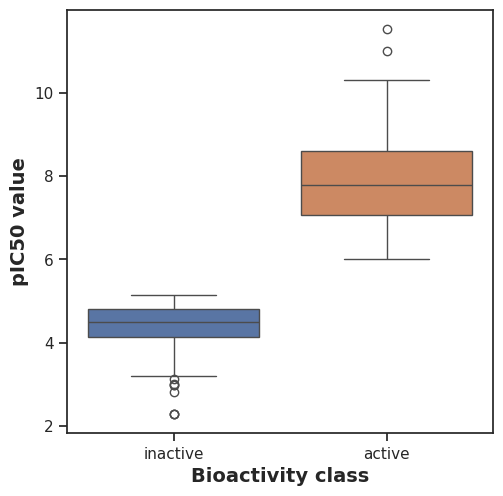

In [46]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = "bioactivity_class", y = "pIC50", data = df_combined, hue="bioactivity_class")

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('pIC50 value', fontsize=14, fontweight='bold')

## **Scatter of Molecular Weight vs Solubility (LogP)**

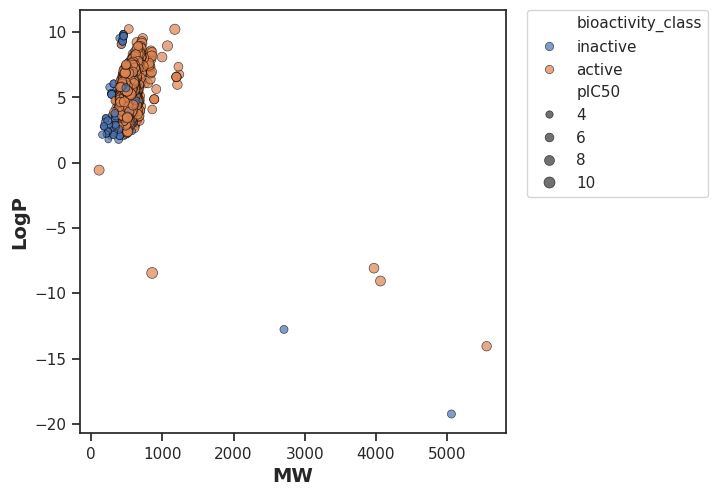

In [47]:
plt.figure(figsize=(5.5, 5.5))

sns.scatterplot(x='MW', y='LogP', data=df_combined, hue='bioactivity_class', size='pIC50', edgecolor='black', alpha=0.7)

plt.xlabel('MW', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0)
plt.savefig('scatter_plot_MW_vs_LogP.pdf')

## **Statistical analysis (Mann-Whitney U Test)**

In [48]:
def mannwhitney(descriptor, df_combined, verbose=False):
    """
    Perform Mann-Whitney U test between active and inactive compounds
    for a given descriptor.

    Parameters:
    - descriptor : str, column name of the descriptor
    - df_combined : pandas DataFrame, must have columns [descriptor, bioactivity_class]
    - verbose : bool, if True prints the test statistics

    Returns:
    - results : pandas DataFrame with test statistics, p-value, and interpretation
    """
    from numpy.random import seed
    from scipy.stats import mannwhitneyu
    import pandas as pd

    # set seed for reproducibility
    seed(1)

    # select only relevant columns
    df = df_combined[[descriptor, 'bioactivity_class']]

    # separate active and inactive compounds
    active = df[df['bioactivity_class'] == 'active'][descriptor]
    inactive = df[df['bioactivity_class'] == 'inactive'][descriptor]

    # perform Mann-Whitney U test
    stat, p = mannwhitneyu(active, inactive)

    if verbose:
        print(f"Descriptor: {descriptor}")
        print(f"Statistics={stat:.3f}, p={p:.3f}")

    # interpret result
    alpha = 0.05
    if p > alpha:
        interpretation = 'Same distribution (fail to reject H0)'
    else:
        interpretation = 'Different distribution (reject H0)'

    # store results in a DataFrame
    results = pd.DataFrame({
        'Descriptor': descriptor,
        'Statistics': stat,
        'p': p,
        'alpha': alpha,
        'Interpretation': interpretation
    }, index=[0])

    # save results to CSV
    filename = 'mannwhitneyu_' + descriptor + '.csv'
    results.to_csv(filename, index=False)

    return results


# **pIC50**

In [49]:
mannwhitney("pIC50", df_combined, verbose=True)

Descriptor: pIC50
Statistics=402380.000, p=0.000


,Descriptor,Statistics,p,alpha,Interpretation
0,pIC50,402380.0,4.410306e-130,0.05,Different distribution (reject H0)


# **Molecular Weight**

In [51]:
mannwhitney("MW", df_combined, verbose=True)

Descriptor: MW
Statistics=293942.000, p=0.000


,Descriptor,Statistics,p,alpha,Interpretation
0,MW,293942.0,4.717355e-29,0.05,Different distribution (reject H0)


# **Solubility LogP**

In [50]:
mannwhitney("LogP", df_combined, verbose=True)

Descriptor: LogP
Statistics=279599.500, p=0.000


,Descriptor,Statistics,p,alpha,Interpretation
0,LogP,279599.5,3.163683e-21,0.05,Different distribution (reject H0)


# **Number of Hydrogen Donors**

In [52]:
mannwhitney("NumHDonors", df_combined, verbose=True)

Descriptor: NumHDonors
Statistics=139588.000, p=0.000


,Descriptor,Statistics,p,alpha,Interpretation
0,NumHDonors,139588.0,4.232726e-16,0.05,Different distribution (reject H0)


# **Number of Hydrogen Acceptors**

In [53]:
mannwhitney("NumHAcceptors", df_combined, verbose=True)

Descriptor: NumHAcceptors
Statistics=209757.500, p=0.289


,Descriptor,Statistics,p,alpha,Interpretation
0,NumHAcceptors,209757.5,0.288556,0.05,Same distribution (fail to reject H0)


# **Combine All Statistical Results**

In [54]:
import pandas as pd
import glob
import os

# Get list of all Mann-Whitney CSV files in current folder
mw_files = glob.glob("mannwhitneyu_*.csv")

# Combine them into one DataFrame
mw_combined = pd.concat([pd.read_csv(f) for f in mw_files], ignore_index=True)

# Save combined CSV
combined_filename = "mannwhitney_summary.csv"
mw_combined.to_csv(combined_filename, index=False)

print(f"Combined Mann-Whitney CSV saved as {combined_filename}")

Combined Mann-Whitney CSV saved as mannwhitney_summary.csv


In [55]:
mw_combined

,Descriptor,Statistics,p,alpha,Interpretation
0,LogP,279599.5,3.163683e-21,0.05,Different distribution (reject H0)
1,NumHDonors,139588.0,4.232726e-16,0.05,Different distribution (reject H0)
2,NumHAcceptors,209757.5,2.885559e-01,0.05,Same distribution (fail to reject H0)
3,MW,293942.0,4.717355e-29,0.05,Different distribution (reject H0)
4,pIC50,402380.0,4.410306e-130,0.05,Different distribution (reject H0)


## **Molecular Weight**

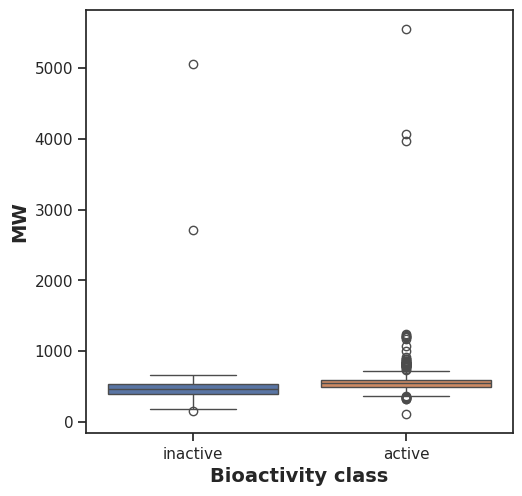

In [56]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'MW', data = df_combined, hue="bioactivity_class")

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('MW', fontsize=14, fontweight='bold')

plt.savefig('boxplot_MW.pdf')


## **logP**

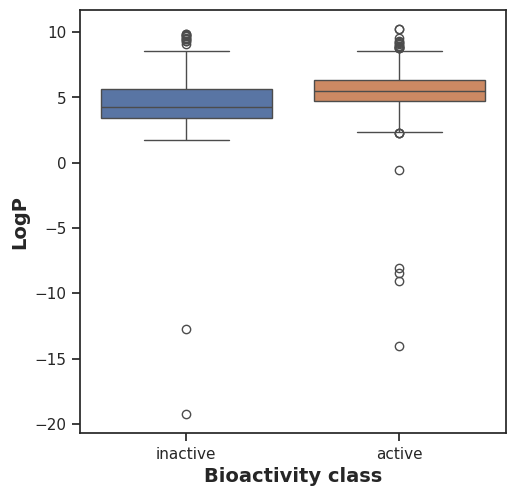

In [57]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = "bioactivity_class", y = 'LogP', data = df_combined, hue="bioactivity_class")

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')

plt.savefig('boxplot_LogP.pdf')

## **NumHDonors**

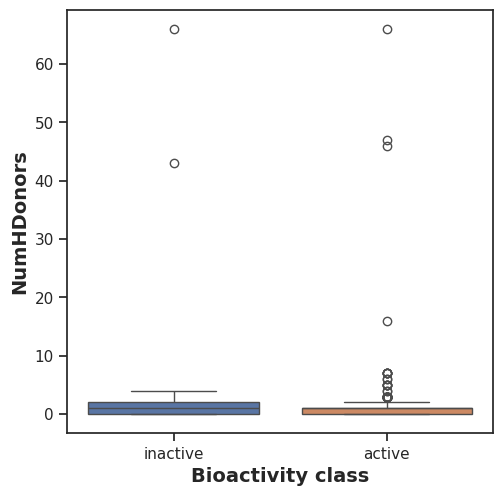

In [58]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = "bioactivity_class", y = "NumHDonors", data = df_combined, hue="bioactivity_class")

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHDonors', fontsize=14, fontweight='bold')

plt.savefig('boxplot_NumHDonors.pdf')

## **NumHAcceptors**

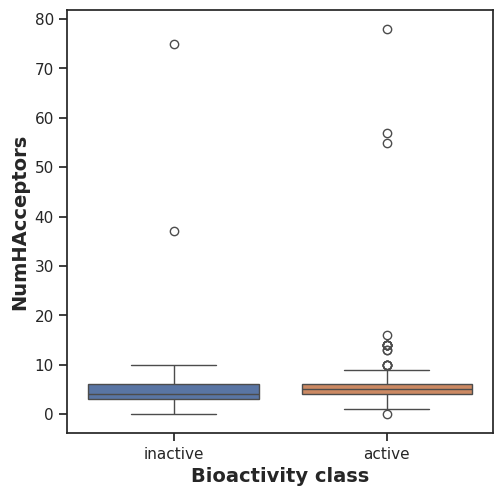

In [59]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = "bioactivity_class", y = "NumHAcceptors", data = df_combined, hue="bioactivity_class")

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHAcceptors', fontsize=14, fontweight='bold')

plt.savefig('boxplot_NumHAcceptors.pdf')

## **Save & Downlaod Results**

In [60]:
! zip -r EDA_results.zip . -i *df_lipinski.csv *mannwhitney_summary.csv *.pdf

	zip warning: name not matched: gdrive
  adding: boxplot_MW.pdf (deflated 39%)
  adding: boxplot_NumHAcceptors.pdf (deflated 37%)
  adding: barplot_bioactivity_class.pdf (deflated 39%)
  adding: mannwhitney_summary.csv (deflated 47%)
  adding: boxplot_LogP.pdf (deflated 39%)
  adding: df_lipinski.csv (deflated 81%)
  adding: scatter_plot_MW_vs_LogP.pdf (deflated 3%)
  adding: boxplot_NumHDonors.pdf (deflated 38%)
  adding: histogram_pic50.pdf (deflated 49%)


# **Part 3: Descriptor Calculation**

PaDELPy is a Python wrapper for the PaDEL-Descriptor (molecular descriptor calculation) software.  

It provide the following descriptors/fingerprint:  
* 1444 - 2D Descriptors
* 431 - 3D Descriptors
* 881 bits - PubChem Fingerprints

## **Install PaDELpy**

In [61]:
!pip install padelpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 47.6 MB/s eta 0:00:00


## **Import libraries**

In [62]:
import pandas as pd
import numpy as np
from google.colab import files
from padelpy import padeldescriptor

## **Load dataset**

In [63]:
df = pd.read_csv('df_lipinski.csv')
df.head()

,molecule_chembl_id,bioactivity_class,pIC50,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors
0,CHEMBL1976682,inactive,3.694083,BrCc1ccc2ccc3ccc(CBr)nc3c2n1,366.056,4.57280,0.0,2.0
1,CHEMBL2281892,active,6.000000,Brc1ccc(COc2ccc(Br)cc2N2CCOCC2)cc1,427.136,4.62720,0.0,3.0
2,CHEMBL93691,active,6.000000,Brc1cccc([C@H]2CN(Cc3ccccc3)C[C@@H]2CN2CCC(c3c...,489.501,6.54430,0.0,2.0
3,CHEMBL2281960,active,7.031984,C/C(=N\NC(=N)N)c1cc(Br)ccc1OCc1ccc(C#N)cc1,386.253,3.10685,3.0,4.0
4,CHEMBL241097,active,6.698981,C/C(=N\NC(=N)N)c1cc(Br)ccc1OCc1ccc(Cl)cc1,395.688,3.88857,3.0,3.0


In [64]:
data = df[['canonical_smiles', 'molecule_chembl_id']]
data.head()

,canonical_smiles,molecule_chembl_id
0,BrCc1ccc2ccc3ccc(CBr)nc3c2n1,CHEMBL1976682
1,Brc1ccc(COc2ccc(Br)cc2N2CCOCC2)cc1,CHEMBL2281892
2,Brc1cccc([C@H]2CN(Cc3ccccc3)C[C@@H]2CN2CCC(c3c...,CHEMBL93691
3,C/C(=N\NC(=N)N)c1cc(Br)ccc1OCc1ccc(C#N)cc1,CHEMBL2281960
4,C/C(=N\NC(=N)N)c1cc(Br)ccc1OCc1ccc(Cl)cc1,CHEMBL241097


## **Convert to .smi format**

In [65]:
df_smi = data['canonical_smiles'].to_csv('smiles_chembl.smi', index=None, header=None)

In [66]:
! cat smiles_chembl.smi | head

BrCc1ccc2ccc3ccc(CBr)nc3c2n1
Brc1ccc(COc2ccc(Br)cc2N2CCOCC2)cc1
Brc1cccc([C@H]2CN(Cc3ccccc3)C[C@@H]2CN2CCC(c3ccccc3)CC2)c1
C/C(=N\NC(=N)N)c1cc(Br)ccc1OCc1ccc(C#N)cc1
C/C(=N\NC(=N)N)c1cc(Br)ccc1OCc1ccc(Cl)cc1
C/C(=N\NC(=N)N)c1cc(Cl)ccc1OCc1ccc(Cl)cc1
C/C=C(\C)[C@@H]1CC[C@@H]2C[C@H](C)C[C@H](C)[C@H]2[C@@H]1/C(O)=C1/C(=O)N[C@H](C[C@@](C)(O)C(=O)O)C1=O
C/C=C(\C)[C@H](CCN1CCC2(CC1)C[S+]([O-])c1ccccc12)CN(C)S(=O)(=O)c1ccccc1
C/C=C(\C)[C@H](CCN1CCC2(CC1)C[S+]([O-])c1ccccc12)CN(C)S(=O)(=O)c1cn(C)cn1
C/C=C/CN1C(=O)C(CC(C)C)NC(=O)C12CCN(Cc1ccc(Oc3ccccc3)cc1)CC2


## **Calculate molecular Pubchem Fingerprints using "padeldescriptor" function**

In [67]:
padeldescriptor(mol_dir= "smiles_chembl.smi",
                d_file='pubchem_fingerprints.csv',
                fingerprints = True,
                retainorder= True,
                #removesalt = True, standardizetautomers = True, standardizenitro=True
                )

In [68]:
!ls -lh pubchem_fingerprints.csv

-rw-r--r-- 1 root root 3.6M Apr  7 09:12 pubchem_fingerprints.csv


In [69]:
df_fingerprint = pd.read_csv("pubchem_fingerprints.csv")
df_fingerprint.head()

,Name,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,PubchemFP7,PubchemFP8,...,PubchemFP871,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880
0,AUTOGEN_smiles_chembl_1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,AUTOGEN_smiles_chembl_2,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,AUTOGEN_smiles_chembl_3,1,1,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,AUTOGEN_smiles_chembl_4,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,AUTOGEN_smiles_chembl_5,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## **Prepare Dataset for ML**

In [70]:
df.head()

,molecule_chembl_id,bioactivity_class,pIC50,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors
0,CHEMBL1976682,inactive,3.694083,BrCc1ccc2ccc3ccc(CBr)nc3c2n1,366.056,4.57280,0.0,2.0
1,CHEMBL2281892,active,6.000000,Brc1ccc(COc2ccc(Br)cc2N2CCOCC2)cc1,427.136,4.62720,0.0,3.0
2,CHEMBL93691,active,6.000000,Brc1cccc([C@H]2CN(Cc3ccccc3)C[C@@H]2CN2CCC(c3c...,489.501,6.54430,0.0,2.0
3,CHEMBL2281960,active,7.031984,C/C(=N\NC(=N)N)c1cc(Br)ccc1OCc1ccc(C#N)cc1,386.253,3.10685,3.0,4.0
4,CHEMBL241097,active,6.698981,C/C(=N\NC(=N)N)c1cc(Br)ccc1OCc1ccc(Cl)cc1,395.688,3.88857,3.0,3.0


In [71]:
# Select only the columns we need for ML
meta_cols = df[['molecule_chembl_id', 'bioactivity_class', 'pIC50']]

# Reset index to ensure proper alignment
meta_cols = meta_cols.reset_index(drop=True)
df_fingerprint = df_fingerprint.reset_index(drop=True)

# Combine meta data with fingerprints
combined_df = pd.concat([meta_cols, df_fingerprint.drop(df_fingerprint.columns[0], axis=1)], axis=1)

# Inspect the first few rows
combined_df.head()


,molecule_chembl_id,bioactivity_class,pIC50,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,...,PubchemFP871,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880
0,CHEMBL1976682,inactive,3.694083,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,CHEMBL2281892,active,6.000000,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,CHEMBL93691,active,6.000000,1,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,CHEMBL2281960,active,7.031984,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,CHEMBL241097,active,6.698981,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## **Save and download the dataset**

In [72]:
# Save as CSV
combined_df.to_csv("QSAR_dataset.csv", index=False)
print("Combined dataset saved as QSAR_dataset.csv")

# Download file in Colab
files.download("QSAR_dataset.csv")

Combined dataset saved as QSAR_dataset.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Calculate other fingerprints**

## **Download xml Files from Github**

In [73]:
!wget https://github.com/AI-Biotechnology-Bioinformatics/Drug_Discovery_AI_Course_2026/raw/main/padel_descriptors_xml.zip

--2026-04-07 09:14:01--  https://github.com/AI-Biotechnology-Bioinformatics/Drug_Discovery_AI_Course_2026/raw/main/padel_descriptors_xml.zip
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/AI-Biotechnology-Bioinformatics/Drug_Discovery_AI_Course_2026/main/padel_descriptors_xml.zip [following]
--2026-04-07 09:14:02--  https://raw.githubusercontent.com/AI-Biotechnology-Bioinformatics/Drug_Discovery_AI_Course_2026/main/padel_descriptors_xml.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10871 (11K) [application/zip]
Saving to: ‘padel_descriptors_xml.zip’

padel_descriptors_x 100%[=============

## **Unzip all files**

In [74]:
!unzip padel_descriptors_xml.zip

Archive:  padel_descriptors_xml.zip
  inflating: AtomPairs2DFingerprintCount.xml  
  inflating: AtomPairs2DFingerprinter.xml  
  inflating: EStateFingerprinter.xml  
  inflating: ExtendedFingerprinter.xml  
  inflating: Fingerprinter.xml       
  inflating: GraphOnlyFingerprinter.xml  
  inflating: KlekotaRothFingerprintCount.xml  
  inflating: KlekotaRothFingerprinter.xml  
  inflating: MACCSFingerprinter.xml  
  inflating: PubchemFingerprinter.xml  
  inflating: SubstructureFingerprintCount.xml  
  inflating: SubstructureFingerprinter.xml  


## **Calculate Fingerprints**

In [75]:
# Specify the XML file for SubstructureFingerprinter directly
Substruc_fp = "SubstructureFingerprinter.xml"

# Calculate Substructure fingerprints
padeldescriptor(
    mol_dir='smiles_chembl.smi',
    d_file='Substructure_fingerprints.csv',
    fingerprints=True,
    descriptortypes= Substruc_fp,
    retainorder=True
    # removesalt=True, standardizetautomers=True
)

## **Part 4: QSAR Modeling**

In [76]:
# Install LazyPredict
!pip install lazypredict

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 3.0 MB/s eta 0:00:00


In [77]:
# Install SHAP
!pip install shap

In [78]:
# Import libraries
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.utils import shuffle
from lazypredict.Supervised import LazyRegressor
import shap

## **Loading the Dataset**

In [79]:
df = pd.read_csv('QSAR_dataset.csv')
df.head()

,molecule_chembl_id,bioactivity_class,pIC50,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,...,PubchemFP871,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880
0,CHEMBL1976682,inactive,3.694083,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,CHEMBL2281892,active,6.000000,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,CHEMBL93691,active,6.000000,1,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,CHEMBL2281960,active,7.031984,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,CHEMBL241097,active,6.698981,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## **Dataset overview:**
- `molecule_chembl_id`: Unique molecule ID
- `bioactivity_class`: Active/inactive class
- `pIC50`: Continuous potency value (4-9)
- `PubchemFP0` to `PubchemFP880`: 881 binary fingerprints

We have 2049 molecules and 884 features plus 3 identifier/target columns.

## **Features (X) and Target (y)**

Features are our PubChem fingerprints. Target is pIC50 for regression.
We'll exclude non-feature columns first.

In [80]:
# Exclude non-feature columns
non_feature_cols = ['molecule_chembl_id', 'bioactivity_class', 'pIC50']
X = df.drop(columns=non_feature_cols)
print(X.shape)

(2049, 881)


In [81]:
# Target variable
y_reg = df['pIC50']
y_reg

,pIC50
0,3.694083
1,6.000000
2,6.000000
3,7.031984
4,6.698981
...,...
2044,6.657577
2045,6.593460
2046,5.000000
2047,4.443697


## **Feature Selection – Variance Threshold**

Not all 881 fingerprints are informative. Low-variance features (mostly 0 or 1) add noise. We remove them using `VarianceThreshold`.

In [82]:
# Apply variance threshold
selection = VarianceThreshold(threshold=(0.8*(1-0.8)))  # Threshold = 0.16
X_var = selection.fit_transform(X)

# Extract the correct feature names
selected_mask = selection.get_support()
feature_names = X.columns[selected_mask]

# Convert immediately to DataFrame
X_var = pd.DataFrame(X_var, columns=feature_names)

print('After variance threshold:', X_var.shape)

After variance threshold: (2049, 157)


**Result:** 171 informative features retained, 10 removed. Reduces noise, speeds up training, and improves generalization.

## **Split Data into Training and Test Set**

In [83]:
# Split into 80/20 train/test
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_var, y_reg, test_size=0.2, random_state=123
)
print(f'Training set size: {X_train_reg.shape[0]} molecules')
print(f'Testing set size: {X_test_reg.shape[0]} molecules')

Training set size: 1639 molecules
Testing set size: 410 molecules


In [107]:
# Save full training dataset
X_train_reg.to_csv("X_train_reg.csv", index=False)

## **Build and Train Random Forest Model**

In [84]:
# Set random seed for reproducibility
np.random.seed(123)

# Create Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=200)

# Train model
rf_model.fit(X_train_reg, y_train_reg)

RandomForestRegressor(n_estimators=200)

In [100]:
import pickle

with open("features.pkl", "wb") as f:
    pickle.dump(X_train_reg.columns.tolist(), f)

## **Evaluate Model's Performance on Test Set**

In [85]:
r2 = rf_model.score(X_test_reg, y_test_reg)
print(f'Random Forest R² score: {r2:.4f}')

Random Forest R² score: 0.7089


## **R² interpretation:**
- **R² < 0.4** → Poor fit.
- **R² < 0.5-0.7** → Moderate/Acceptable.
- **R² > 0.9** → Very good/High fit

Other metrics like **RMSE** or **MAE** can also be used.

## **Make Predictions on test set**

In [86]:
# Predict on test set
y_pred_reg = rf_model.predict(X_test_reg)

In [87]:
y_pred_reg

array([7.91340103, 4.19089817, 8.69114842, 8.31178487, 8.83799223,
       8.97082886, 7.14068531, 4.88116278, 6.99630646, 7.64925338,
       7.13052911, 9.22553531, 7.31575582, 4.03310699, 7.10093049,
       4.91591203, 7.42927133, 8.38006421, 7.24114379, 8.76158675,
       8.20138128, 6.8751003 , 9.22553531, 7.5389623 , 6.88624724,
       8.70652876, 6.85859061, 7.55903172, 7.50556044, 9.22553531,
       6.44937955, 8.61842625, 7.76599631, 7.62020694, 7.48237402,
       7.65610228, 4.16164193, 4.57001671, 7.79080029, 6.5124506 ,
       6.94831056, 8.1428419 , 8.16285411, 9.63251438, 4.52423346,
       8.4346618 , 8.90012094, 5.45818236, 6.99630646, 6.8149617 ,
       7.15381447, 8.44064082, 6.97721314, 4.5996767 , 6.89457362,
       6.54536851, 7.44098213, 8.88619061, 7.54297713, 9.22553531,
       6.85418667, 6.39454297, 9.22553531, 4.20909048, 4.97265572,
       4.00567868, 8.44064082, 6.04646571, 8.38181065, 6.69105875,
       7.84461134, 7.84587031, 8.88619061, 7.80339786, 8.79983

**y_test_reg**       ..............# actual pIC50  
**y_pred_reg**       ..............# predicted pIC50 values from model

## **Visualize Predictions vs Actual Values**

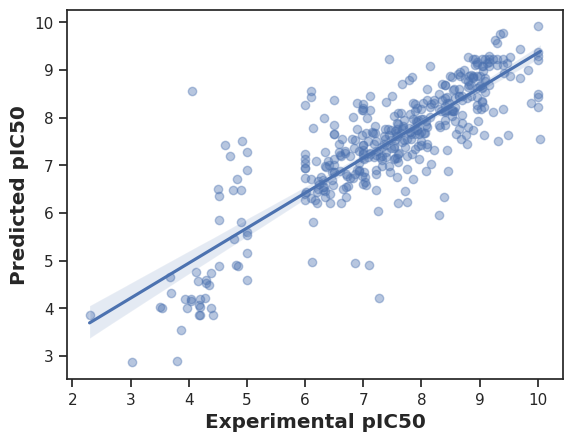

In [88]:
ax = sns.regplot(x=y_test_reg, y=y_pred_reg, scatter_kws={'alpha':0.4})
ax.set_xlabel('Experimental pIC50', fontsize='large', fontweight='bold')
ax.set_ylabel('Predicted pIC50', fontsize='large', fontweight='bold')
plt.show()

## **Y-Randomization – Validate Model**

In [89]:
n_iterations = 5
random_r2_scores = []

for i in range(n_iterations):
    y_train_shuffled = shuffle(y_train_reg, random_state=i)
    rf_random = RandomForestRegressor(n_estimators=200, random_state=42)
    rf_random.fit(X_train_reg, y_train_shuffled)
    y_pred_random = rf_random.predict(X_test_reg)
    r2_random = r2_score(y_test_reg, y_pred_random)
    random_r2_scores.append(r2_random)

print('\nY-Randomization Test Results:')
print(f'Mean R² with shuffled Y: {np.mean(random_r2_scores):.4f}')
print(f'Actual RF R²: {r2:.4f}')


Y-Randomization Test Results:
Mean R² with shuffled Y: -0.2611
Actual RF R²: 0.7089


### **Interpretation:**
- Actual RF R² = 0.0.71,   
- Random R² ≈ -0.26 → Model is learning real chemical patterns, not noise.

# Save Model as Pickle Object

In [90]:
import pickle

In [95]:
pickle.dump(rf_model, open('CC_chemokine_receptor_type_5_model.pkl', 'wb'))

In [96]:
from google.colab import files
files.download('CC_chemokine_receptor_type_5_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **LazyPredict – Compare Multiple Regression Models**

In [92]:
print('\n' + '='*60)
print('LAZYPREDICT - COMPARING MULTIPLE REGRESSION MODELS')
print('='*60)

# Initialize LazyRegressor
reg = LazyRegressor(verbose=0, ignore_warnings=True, custom_metric=None)

# Fit all models
models, predictions = reg.fit(X_train_reg, X_test_reg, y_train_reg, y_test_reg)

# Display results
print(models.head(10))  # Top 10 models


LAZYPREDICT - COMPARING MULTIPLE REGRESSION MODELS
                               Adjusted R-Squared  R-Squared      RMSE  \
Model                                                                    
RandomForestRegressor                    0.516027   0.701806  0.807563   
LGBMRegressor                            0.503606   0.694154  0.817860   
BaggingRegressor                         0.496829   0.689978  0.823424   
NuSVR                                    0.491271   0.686553  0.827960   
HistGradientBoostingRegressor            0.487830   0.684433  0.830755   
SVR                                      0.475437   0.676797  0.840746   
MLPRegressor                             0.456778   0.665301  0.855568   
KNeighborsRegressor                      0.437973   0.653715  0.870250   
XGBRegressor                             0.437017   0.653126  0.870990   
GradientBoostingRegressor                0.421467   0.643544  0.882937   

                               Time Taken  
Model          

## **Visualize Top Models**

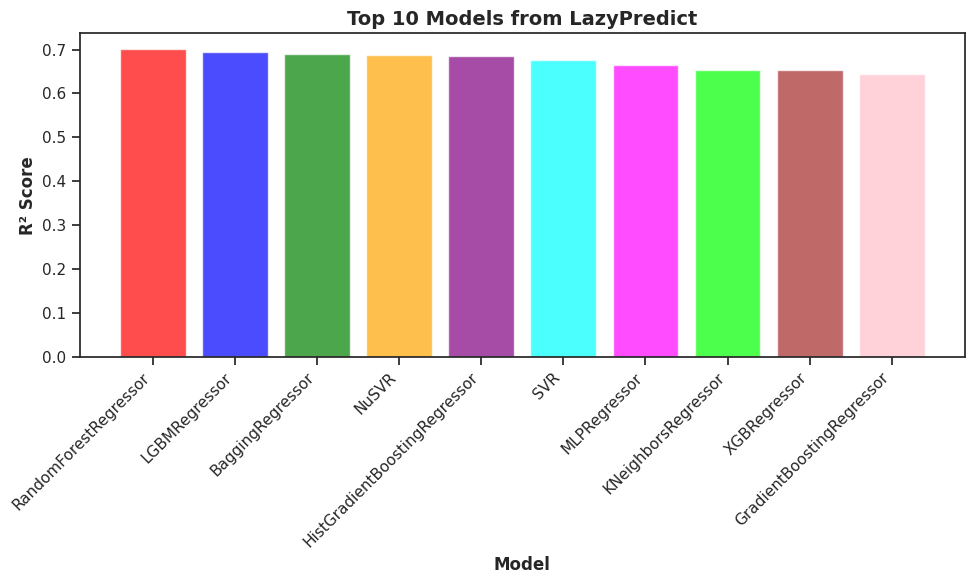

In [93]:
top_models = models.head(10)

plt.figure(figsize=(10, 6))

# Define distinct colors for each bar
colors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan', 'magenta', 'lime', 'brown', 'pink']

# Vertical bar plot with multiple colors and alpha for transparency
plt.bar(top_models.index, top_models['R-Squared'], color=colors, alpha=0.7)

plt.ylabel('R² Score', fontsize=12, fontweight='bold')
plt.xlabel('Model', fontsize=12, fontweight='bold')
plt.title('Top 10 Models from LazyPredict', fontsize=14, fontweight='bold')

# Rotate x-axis labels for readability
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()